# Maze RL — обучение агента проходить лабиринт

В этом ноутбуке мы обучим свёрточную нейросеть проходить лабиринт 21×21
методом PPO (Proximal Policy Optimization).

Будет три этапа обучения:

1. **Исследование** — агент учится посещать новые клетки.
2. **Поиск выхода** — агент учится доходить до выхода как можно быстрее.
3. **Кратчайший путь** — агент учится идти строго по кратчайшему пути.

План ноутбука:

1. Генератор лабиринтов (Краскал на сетке).
2. Среда `MazeEnv` (numpy-only, поддерживает несколько игр одновременно).
3. Свёрточная сеть Actor-Critic.
4. Реализация PPO.
5. Обучение трёх этапов.
6. Визуализация решений и attention-карт активаций.


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

import random
import hashlib
import time
import copy
from collections import deque

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

# Воспроизводимость
np.random.seed(0)
torch.manual_seed(0)
random.seed(0)


Device: cpu


## 1. Генератор лабиринтов

Лабиринт строится алгоритмом Краскала: берём полную решётку клеток,
строим случайное остовное дерево, оставляем только рёбра остова —
получается идеальный лабиринт без циклов.

Размер лабиринта на выходе — `2*n + 1`, при `n = 10` это `21×21`.
Вход: `(1, 0)`, выход: `(19, 20)`.


In [2]:
# ========== disjoint_set.py ==========
from typing import List, Any

class DisjointSet:
    def __init__(self, items: List[Any]):
        self.items = items
        self.parent = [idx for idx in range(len(items))]
        self.size = [1 for _ in range(len(items))]

    def find(self, x: int) -> int:
        item = x
        while item != self.parent[item]:
            item = self.parent[item]
        root = item
        while x != root:
            parent = self.parent[x]
            self.parent[x] = root
            x = parent
        return root

    def union(self, a: int, b: int) -> int:
        root_a = self.find(a)
        root_b = self.find(b)
        if root_a != root_b:
            if self.size[root_a] < self.size[root_b]:
                self.size[root_b] += self.size[root_a]
                self.parent[root_a] = root_b
            else:
                self.size[root_a] += self.size[root_b]
                self.parent[root_b] = root_a
        return root_a


# ========== rectangular_kruskal_maze.py ==========

class KruskalRectangular:
    def __init__(self, n):
        self.n = n
        self.total_cells = n ** 2
        self.TOP = 0
        self.RIGHT = 1
        self.BOTTOM = 2
        self.LEFT = 3

    def create_graph(self):
        edges = []
        for row in range(self.n):
            for col in range(self.n):
                node = self.n * row + col
                if col < self.n - 1:
                    right_node = node + 1
                    edges.append((node, right_node))
                if row < self.n - 1:
                    bottom_node = node + self.n
                    edges.append((node, bottom_node))
        return edges

    def kruskal_spanning_tree(self):
        edges_of_graph = self.create_graph()
        spanning_tree = {
            cell: [0, 0, 0, 0] for cell in range(self.total_cells)
        }
        edges = []
        cells = [idx for idx in range(self.total_cells)]
        disjoint = DisjointSet(cells)
        random.shuffle(edges_of_graph)

        for edge in edges_of_graph:
            cell1, cell2 = edge
            if disjoint.find(cell1) != disjoint.find(cell2):
                disjoint.union(cell1, cell2)
                direction = self.get_neighbour_dir(cell1, cell2)
                spanning_tree[cell1][direction] = 1
                neighbour_dir = self.get_neighbour_dir(cell2, cell1)
                spanning_tree[cell2][neighbour_dir] = 1
                edges.append(edge)
        return spanning_tree, edges

    def get_neighbour_dir(self, cell1, cell2):
        if cell1 == cell2 + self.n:
            return self.TOP
        elif cell1 == cell2 - 1:
            return self.RIGHT
        elif cell1 == cell2 + 1:
            return self.LEFT
        elif cell1 == cell2 - self.n:
            return self.BOTTOM


# ========== maze_generator.py ==========

def make_maze(n: int) -> np.ndarray:
    algo = KruskalRectangular(n)
    spanning_tree, edges = algo.kruskal_spanning_tree()

    size = 2 * n + 1
    result = np.zeros((size, size), dtype=np.int32)

    for i in range(n):
        for j in range(n):
            y, x, node = 2 * i + 1, 2 * j + 1, i * n + j

            result[y, x] = 1
            result[y, x + 1] = j + 1 < n and spanning_tree[node][algo.RIGHT]  or result[y, x + 1]
            result[y + 1, x] = i + 1 < n and spanning_tree[node][algo.BOTTOM] or result[y + 1, x]

    result[1, 0] = result[-2, -1] = 1

    return result, edges


def generate_mazes(n: int, maze_size: int) -> np.ndarray:
    result = []
    hashes = { 'PLACEHOLDER' }

    for i in range(n):
        if (i+1) % 1000 == 0:
            print(f'  {i+1}/{n} mazes generated')
        key = 'PLACEHOLDER'
        while key in hashes:
            maze, edges = make_maze(maze_size)
            key = hashlib.sha256(str(edges).encode()).hexdigest()
        else:
            hashes.add(key)

        result.append(maze)

    return np.stack(result)


Размер: (21, 21)   вход: 1   выход: 1


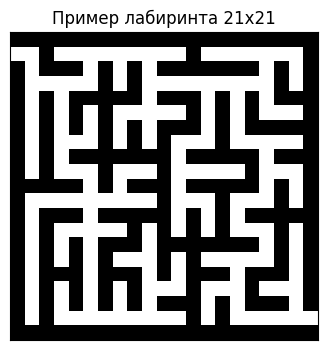

In [3]:
# Покажем один лабиринт для проверки
np.random.seed(0); random.seed(0)
sample, _ = make_maze(10)
print("Размер:", sample.shape, "  вход:", sample[1, 0], "  выход:", sample[19, 20])

plt.figure(figsize=(4, 4))
plt.imshow(sample, cmap="binary_r")
plt.title("Пример лабиринта 21x21")
plt.xticks([]); plt.yticks([])
plt.show()


## 2. BFS — расстояние до выхода и кратчайший путь

Эти величины пригодятся:

* Награде Stage 3 нужен кратчайший путь.
* Для оценки качества — насколько агент сошёл с оптимального маршрута.

Лабиринт — это дерево, поэтому кратчайший путь от старта до финиша
единственный.


In [4]:
def bfs_distances(maze, target=(19, 20)):
    """Расстояние в шагах от каждой клетки до target. Стены = -1."""
    h, w = maze.shape
    dist = np.full((h, w), -1, dtype=np.int32)
    dist[target] = 0
    queue = deque([target])
    while queue:
        r, c = queue.popleft()
        for dr, dc in ((1, 0), (-1, 0), (0, 1), (0, -1)):
            nr, nc = r + dr, c + dc
            if 0 <= nr < h and 0 <= nc < w and maze[nr, nc] == 1 and dist[nr, nc] < 0:
                dist[nr, nc] = dist[r, c] + 1
                queue.append((nr, nc))
    return dist


def shortest_path_mask(maze, start=(1, 0), end=(19, 20)):
    """Маска кратчайшего пути start->end (1 на пути, 0 иначе)."""
    h, w = maze.shape
    parent = {start: None}
    queue = deque([start])
    while queue:
        r, c = queue.popleft()
        if (r, c) == end:
            break
        for dr, dc in ((1, 0), (-1, 0), (0, 1), (0, -1)):
            nr, nc = r + dr, c + dc
            if 0 <= nr < h and 0 <= nc < w and maze[nr, nc] == 1 and (nr, nc) not in parent:
                parent[(nr, nc)] = (r, c)
                queue.append((nr, nc))

    mask = np.zeros((h, w), dtype=np.float32)
    cell = end
    while cell is not None:
        mask[cell] = 1.0
        cell = parent[cell]
    return mask


def precompute_solutions(mazes):
    """Считаем расстояние до выхода и маску кратчайшего пути для всех лабиринтов."""
    n = len(mazes)
    dists = np.zeros_like(mazes, dtype=np.float32)
    paths = np.zeros_like(mazes, dtype=np.float32)
    for i, m in enumerate(mazes):
        d = bfs_distances(m)
        d[d < 0] = 9999.0
        dists[i] = d
        paths[i] = shortest_path_mask(m)
        if (i + 1) % 2000 == 0:
            print(f"  BFS: {i + 1}/{n}")
    return dists, paths


## 3. Среда

Среда `MazeEnv` ведёт сразу `n_envs` параллельных игр — это ключ
к производительности PPO. Все операции — numpy, без Python-циклов
по среде, что соответствует требованию задачи (numpy-only).

### Наблюдение

Целочисленная матрица `21×21` со значениями 0..4:

* `0` — стена,
* `1` — коридор,
* `2` — посещённая клетка,
* `3` — последняя посещённая клетка,
* `4` — текущая клетка.

Сети мы передаём не саму матрицу, а её one-hot представление —
пять каналов `(N, 5, 21, 21)`. Так свёрткам легче работать.

### Действия

* `0` — вниз
* `1` — вправо
* `2` — вверх
* `3` — влево

Шаг в стену оставляет агента на месте (но засчитывается как шаг).

### Награды по этапам

Каждый этап — отдельная функция награды. Этапы независимы, никаких
"кумулятивных бонусов от предыдущей стадии":

* **Stage 1 (исследование):** `+0.05` за каждую новую клетку,
  `+1.0` за выход. Никаких штрафов за шаги.
* **Stage 2 (поиск выхода):** `-0.01` за каждый шаг, `+1.0` за выход.
* **Stage 3 (кратчайший путь):** `-0.01` за шаг, `+0.05` если шаг
  сделан по кратчайшему пути и `-0.05` если не по нему, `+1.0` за выход.

### Авто-рестарт

После завершения эпизода (выход или таймаут) среда сама заменяет
эту игру на новый случайный лабиринт. Это даёт постоянный поток
данных для обучения.


In [5]:
class MazeEnv:
    """Векторизованная среда лабиринта на чистом numpy.

    Attributes:
        n_envs: сколько игр идёт параллельно.
        max_steps: лимит шагов на эпизод.
        stage: 1, 2 или 3 — определяет функцию награды.
    """

    # Положение входа и выхода фиксированы для maze_size=10
    START = (1, 0)
    EXIT = (19, 20)
    GRID = 21

    # Действия: 0-вниз, 1-вправо, 2-вверх, 3-влево
    DR = np.array([1, 0, -1, 0], dtype=np.int32)
    DC = np.array([0, 1, 0, -1], dtype=np.int32)

    N_CHANNELS = 5  # one-hot из значений 0..4

    def __init__(self, maze_pool, n_envs, max_steps=400, stage=1,
                 dist_pool=None, sp_pool=None, seed=None):
        self.pool = maze_pool.astype(np.int32)
        self.dist_pool = dist_pool
        self.sp_pool = sp_pool
        self.n_envs = n_envs
        self.max_steps = max_steps
        self.stage = stage
        self.rng = np.random.default_rng(seed)

        # Состояние всех игр одновременно
        self.mazes = np.zeros((n_envs, self.GRID, self.GRID), dtype=np.int32)
        self.dists = np.zeros((n_envs, self.GRID, self.GRID), dtype=np.float32)
        self.sps = np.zeros((n_envs, self.GRID, self.GRID), dtype=np.float32)
        self.visited = np.zeros((n_envs, self.GRID, self.GRID), dtype=bool)
        self.cur_r = np.zeros(n_envs, dtype=np.int32)
        self.cur_c = np.zeros(n_envs, dtype=np.int32)
        self.prev_r = np.zeros(n_envs, dtype=np.int32)
        self.prev_c = np.zeros(n_envs, dtype=np.int32)
        self.steps = np.zeros(n_envs, dtype=np.int32)
        self.done = np.zeros(n_envs, dtype=bool)

        self.reset()

    def reset(self, idx=None):
        """Пересоздать игры (по умолчанию — все).

        Возвращает текущее наблюдение.
        """
        if idx is None:
            idx = np.arange(self.n_envs)

        # Случайный лабиринт из пула
        new_idx = self.rng.integers(0, len(self.pool), size=len(idx))
        self.mazes[idx] = self.pool[new_idx]
        if self.dist_pool is not None:
            self.dists[idx] = self.dist_pool[new_idx]
        if self.sp_pool is not None:
            self.sps[idx] = self.sp_pool[new_idx]

        self.cur_r[idx] = self.START[0]
        self.cur_c[idx] = self.START[1]
        self.prev_r[idx] = self.START[0]
        self.prev_c[idx] = self.START[1]
        self.steps[idx] = 0
        self.done[idx] = False
        self.visited[idx] = False
        self.visited[idx, self.START[0], self.START[1]] = True
        return self.observation()

    def observation(self):
        """One-hot тензор (N, 5, 21, 21) из значений 0..4."""
        N, G = self.n_envs, self.GRID
        # Сначала строим целочисленную матрицу состояния
        state = self.mazes.copy()                 # 0=стена, 1=коридор
        # Посещённые клетки -> 2 (но не текущая и не последняя)
        state = np.where(self.visited, 2, state)
        # Последняя посещённая (предыдущая позиция) -> 3
        I = np.arange(N)
        state[I, self.prev_r, self.prev_c] = 3
        # Текущая позиция -> 4
        state[I, self.cur_r, self.cur_c] = 4

        # One-hot вдоль оси каналов
        one_hot = np.zeros((N, self.N_CHANNELS, G, G), dtype=np.float32)
        for k in range(self.N_CHANNELS):
            one_hot[:, k] = (state == k).astype(np.float32)
        return one_hot

    def step(self, actions):
        """Сделать шаг во всех средах одновременно.

        Возвращает (observation, reward, done, info).
        """
        N = self.n_envs
        I = np.arange(N)

        # Сохраняем старую позицию
        old_r = self.cur_r.copy()
        old_c = self.cur_c.copy()

        # Целевая позиция (с учётом действия)
        new_r = np.clip(self.cur_r + self.DR[actions], 0, self.GRID - 1)
        new_c = np.clip(self.cur_c + self.DC[actions], 0, self.GRID - 1)

        # Можно сделать шаг? Только если не в стену и игра жива
        alive = ~self.done
        is_corridor = self.mazes[I, new_r, new_c] == 1
        moved = alive & is_corridor

        # Обновляем позицию (только там где можно)
        self.cur_r = np.where(moved, new_r, self.cur_r)
        self.cur_c = np.where(moved, new_c, self.cur_c)
        self.prev_r = np.where(moved, old_r, self.prev_r)
        self.prev_c = np.where(moved, old_c, self.prev_c)

        # Какие клетки только что увидели в первый раз?
        first_visit = moved & ~self.visited[I, self.cur_r, self.cur_c]
        self.visited[I, self.cur_r, self.cur_c] = True

        # Удар в стену
        bumped = alive & ~is_corridor

        # Шагнули и не дошли — счётчик шагов
        self.steps += alive.astype(np.int32)

        # Достиг выхода?
        reached = (self.cur_r == self.EXIT[0]) & (self.cur_c == self.EXIT[1]) & alive
        timeout = alive & (self.steps >= self.max_steps) & ~reached

        # === Награды ===
        reward = self._compute_reward(
            alive=alive, moved=moved, bumped=bumped,
            first_visit=first_visit, reached=reached, timeout=timeout,
        )

        # Завершение
        self.done = self.done | reached | timeout

        info = {
            "reached": reached.copy(),
            "timeout": timeout.copy(),
            "steps": self.steps.copy(),
        }
        return self.observation(), reward, self.done.copy(), info

    def _compute_reward(self, alive, moved, bumped, first_visit, reached, timeout):
        """Награда зависит от текущего этапа обучения."""
        N = self.n_envs
        I = np.arange(N)
        rew = np.zeros(N, dtype=np.float32)

        if self.stage == 1:
            # Исследование: радуемся новым клеткам, очень рады выходу
            rew += first_visit.astype(np.float32) * 0.05
            rew += reached.astype(np.float32) * 1.0

        elif self.stage == 2:
            # Поиск выхода: каждый шаг немного штрафуется
            rew -= alive.astype(np.float32) * 0.01
            rew += reached.astype(np.float32) * 1.0

        elif self.stage == 3:
            # Кратчайший путь: вне SP — штраф, на SP — маленький бонус
            rew -= alive.astype(np.float32) * 0.01
            rew += reached.astype(np.float32) * 1.0
            on_sp = self.sps[I, self.cur_r, self.cur_c] > 0.5
            # Учитываем только реальные шаги (если стояли — нечего штрафовать)
            rew += (moved & on_sp).astype(np.float32) * 0.05
            rew -= (moved & ~on_sp).astype(np.float32) * 0.05

        return rew

    def auto_reset(self):
        """Перезапускает игры, в которых эпизод закончился. Возвращает новое наблюдение."""
        finished = np.where(self.done)[0]
        if len(finished) > 0:
            self.reset(finished)
        return self.observation()


In [6]:
# Маленькая проверка среды: случайный агент, 100 шагов в 4 средах одновременно
np.random.seed(0); random.seed(0)
demo_pool = generate_mazes(4, maze_size=10)
demo_dist, demo_sp = precompute_solutions(demo_pool)

env = MazeEnv(demo_pool, n_envs=4, max_steps=200, stage=1,
              dist_pool=demo_dist, sp_pool=demo_sp, seed=0)
obs = env.observation()
print("Форма наблюдения:", obs.shape, " — должно быть (4, 5, 21, 21)")
print("Сумма каналов в одной клетке = 1 (one-hot)?",
      np.allclose(obs.sum(axis=1), 1.0))

total_reward = np.zeros(4)
for _ in range(100):
    act = np.random.randint(0, 4, size=4)
    obs, rew, done, info = env.step(act)
    total_reward += rew
    obs = env.auto_reset()
print("Награды случайного агента после 100 шагов:", total_reward)


Форма наблюдения: (4, 5, 21, 21)  — должно быть (4, 5, 21, 21)
Сумма каналов в одной клетке = 1 (one-hot)? True
Награды случайного агента после 100 шагов: [0.45000001 0.3        0.40000001 0.65000001]


## 4. Сеть Actor-Critic

Архитектура:

* Вход: `(B, 5, 21, 21)` — one-hot.
* Несколько свёрточных блоков с `padding=1`, чтобы пространственный
  размер не уменьшался — нам важна каждая клетка.
* Финальный flatten + два головы: политика (4 действия) и value.

Выбор архитектуры:

* Размер `21×21` маленький, агрессивный stride сильно теряет
  локальную информацию (важна детальная картина стен).
* ResNet-блоки сохраняют разрешение и дают сети глубину.
* Внутри сети поле зрения растёт линейно с глубиной — после 6
  свёрток `3×3` каждая выходная клетка "видит" окно `13×13`,
  чего достаточно для принятия локальных решений.


In [7]:
class ResBlock(nn.Module):
    """Простой residual-блок: две свёртки 3x3, identity skip."""

    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        h = F.relu(self.conv1(x))
        h = self.conv2(h)
        return F.relu(x + h)


class MazeNet(nn.Module):
    """Свёрточный actor-critic для лабиринта.

    Вход: (B, 5, 21, 21).
    Выход: logits (B, 4), value (B,).
    """

    def __init__(self, in_channels=5, channels=64, n_blocks=4):
        super().__init__()
        self.stem = nn.Conv2d(in_channels, channels, kernel_size=3, padding=1)
        self.blocks = nn.Sequential(*[ResBlock(channels) for _ in range(n_blocks)])

        # Перед головами — flatten всей карты
        flat_dim = channels * 21 * 21
        self.shared = nn.Sequential(
            nn.Linear(flat_dim, 256),
            nn.ReLU(),
        )
        self.policy_head = nn.Linear(256, 4)
        self.value_head = nn.Linear(256, 1)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)
        # Голова политики — маленькая инициализация (классика для PPO)
        nn.init.orthogonal_(self.policy_head.weight, gain=0.01)
        nn.init.zeros_(self.policy_head.bias)

    def features(self, x):
        h = F.relu(self.stem(x))
        h = self.blocks(h)
        return h

    def forward(self, x):
        h = self.features(x)
        flat = h.flatten(1)
        h = self.shared(flat)
        logits = self.policy_head(h)
        value = self.value_head(h).squeeze(-1)
        return logits, value

    def act(self, obs, action=None):
        """Семплирует действие (или вычисляет log_prob для заданного)."""
        logits, value = self.forward(obs)
        dist = Categorical(logits=logits)
        if action is None:
            action = dist.sample()
        return action, dist.log_prob(action), dist.entropy(), value


_test = MazeNet().to(device)
print(_test)


MazeNet(
  (stem): Conv2d(5, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (blocks): Sequential(
    (0): ResBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (1): ResBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (2): ResBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (3): ResBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
  )
  (shared): Sequential(
    (0): Linear(in_features=28224, out_features=256, bias=True)
    (1): ReLU()
  )
  (policy_head): Linear(in_featu

In [8]:
# Сколько параметров в каждой части сети + какой размер активаций после каждого блока
def architecture_summary(model, input_shape=(1, 5, 21, 21)):
    # Считаем параметры по группам верхнего уровня
    print(f"{'модуль':<20} {'параметров':>15}")
    print("-" * 36)
    total = 0
    for name, child in model.named_children():
        n = sum(p.numel() for p in child.parameters())
        total += n
        print(f"{name:<20} {n:>15,}")
    print("-" * 36)
    print(f"{'итого':<20} {total:>15,}")

    # Прогоним фиктивный тензор и посмотрим размеры на каждом этапе
    print(f"\nразмеры активаций при входе {input_shape}:")
    x = torch.zeros(*input_shape, device=next(model.parameters()).device)
    with torch.no_grad():
        h = F.relu(model.stem(x));     print(f"  после stem:        {tuple(h.shape)}")
        for i, block in enumerate(model.blocks):
            h = block(h);              print(f"  после ResBlock #{i}: {tuple(h.shape)}")
        flat = h.flatten(1);           print(f"  после flatten:     {tuple(flat.shape)}")
        s = model.shared(flat);        print(f"  после shared FC:   {tuple(s.shape)}")
        pi = model.policy_head(s);     print(f"  policy logits:     {tuple(pi.shape)}")
        v = model.value_head(s);       print(f"  value:             {tuple(v.shape)}")

architecture_summary(_test)
del _test


модуль                    параметров
------------------------------------
stem                           2,944
blocks                       295,424
shared                     7,225,600
policy_head                    1,028
value_head                       257
------------------------------------
итого                      7,525,253

размеры активаций при входе (1, 5, 21, 21):
  после stem:        (1, 64, 21, 21)
  после ResBlock #0: (1, 64, 21, 21)
  после ResBlock #1: (1, 64, 21, 21)
  после ResBlock #2: (1, 64, 21, 21)
  после ResBlock #3: (1, 64, 21, 21)
  после flatten:     (1, 28224)
  после shared FC:   (1, 256)
  policy logits:     (1, 4)
  value:             (1, 1)


## 5. PPO

Реализация по
[OpenAI Spinning Up](https://spinningup.openai.com/en/latest/algorithms/ppo.html).

Ключевые элементы:

* **Clipped surrogate**: `L = min(r·A, clip(r, 1±ε)·A)`.
* **GAE-λ** для оценки advantage.
* **KL early-stop** — выходим из эпохи если KL-дивергенция
  превысила порог.
* **Линейный спад learning rate**.
* **Энтропийный бонус** — поощряем разнообразие действий.


In [9]:
class RolloutBuffer:
    """Буфер на n_steps шагов в n_envs параллельных средах."""

    def __init__(self, n_steps, n_envs, obs_shape):
        self.n_steps = n_steps
        self.n_envs = n_envs
        shape = (n_steps, n_envs)
        self.obs = np.zeros(shape + obs_shape, dtype=np.float32)
        self.actions = np.zeros(shape, dtype=np.int64)
        self.log_probs = np.zeros(shape, dtype=np.float32)
        self.rewards = np.zeros(shape, dtype=np.float32)
        self.dones = np.zeros(shape, dtype=np.float32)
        self.values = np.zeros(shape, dtype=np.float32)
        self.ptr = 0

    def reset(self):
        self.ptr = 0

    def store(self, obs, act, logp, rew, done, val):
        self.obs[self.ptr] = obs
        self.actions[self.ptr] = act
        self.log_probs[self.ptr] = logp
        self.rewards[self.ptr] = rew
        self.dones[self.ptr] = done
        self.values[self.ptr] = val
        self.ptr += 1

    def compute_gae(self, last_values, last_dones, gamma=0.99, lam=0.95):
        """Generalized Advantage Estimation."""
        adv = np.zeros_like(self.rewards)
        gae = 0.0
        for t in reversed(range(self.n_steps)):
            if t == self.n_steps - 1:
                next_v = last_values
                next_done = last_dones
            else:
                next_v = self.values[t + 1]
                next_done = self.dones[t + 1]
            delta = self.rewards[t] + gamma * next_v * (1 - next_done) - self.values[t]
            gae = delta + gamma * lam * (1 - next_done) * gae
            adv[t] = gae
        returns = adv + self.values
        return adv, returns

    def iter_minibatches(self, advantages, returns, batch_size):
        """Перемешиваем все T*N примеров и выдаём минибатчи."""
        total = self.n_steps * self.n_envs
        order = np.random.permutation(total)

        # Расплющиваем (T, N, ...) -> (T*N, ...)
        def flat(x):
            return x.reshape((total,) + x.shape[2:]) if x.ndim > 2 else x.reshape(total)

        obs = flat(self.obs)
        actions = flat(self.actions)
        log_probs = flat(self.log_probs)
        values = flat(self.values)
        adv = flat(advantages)
        ret = flat(returns)

        for start in range(0, total, batch_size):
            idx = order[start:start + batch_size]
            yield (
                torch.as_tensor(obs[idx], device=device),
                torch.as_tensor(actions[idx], device=device),
                torch.as_tensor(log_probs[idx], device=device),
                torch.as_tensor(values[idx], device=device),
                torch.as_tensor(adv[idx], device=device),
                torch.as_tensor(ret[idx], device=device),
            )


In [10]:
class PPO:
    """PPO с GAE, KL early stopping и линейным LR-спадом."""

    def __init__(self, model, lr=3e-4, gamma=0.99, lam=0.95,
                 clip=0.1, ent_coef=0.02, val_coef=0.5,
                 max_grad_norm=0.5, n_epochs=3, batch_size=1024,
                 target_kl=0.015, total_iters=1000):
        self.model = model
        self.gamma = gamma
        self.lam = lam
        self.clip = clip
        self.ent_coef = ent_coef
        self.val_coef = val_coef
        self.max_grad_norm = max_grad_norm
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.target_kl = target_kl

        self.lr_start = lr
        self.total_iters = total_iters
        self.iter_count = 0

        self.optimizer = optim.Adam(model.parameters(), lr=lr, eps=1e-5)

    def collect_rollout(self, env, buffer, obs):
        """Собираем n_steps шагов в каждой среде, складываем в buffer."""
        buffer.reset()
        episode_log = []

        for _ in range(buffer.n_steps):
            with torch.no_grad():
                obs_t = torch.as_tensor(obs, device=device)
                action, logp, _, value = self.model.act(obs_t)

            a = action.cpu().numpy()
            lp = logp.cpu().numpy()
            v = value.cpu().numpy()

            next_obs, reward, done, info = env.step(a)
            buffer.store(obs, a, lp, reward, done.astype(np.float32), v)

            # Регистрируем закончившиеся эпизоды
            for i in range(env.n_envs):
                if info["reached"][i] or info["timeout"][i]:
                    episode_log.append({
                        "reached": bool(info["reached"][i]),
                        "steps": int(info["steps"][i]),
                    })

            obs = env.auto_reset()
        return obs, episode_log

    def update(self, buffer, last_values, last_dones):
        """Обновляем сеть несколькими эпохами по всем собранным данным."""
        self.iter_count += 1
        # Линейный спад learning rate
        progress = min(self.iter_count / self.total_iters, 1.0)
        lr = self.lr_start * (1.0 - progress) + self.lr_start * 0.1 * progress
        for pg in self.optimizer.param_groups:
            pg["lr"] = lr

        adv, returns = buffer.compute_gae(last_values, last_dones, self.gamma, self.lam)
        # Нормализация advantage по батчу — стабильность
        adv_norm = (adv - adv.mean()) / (adv.std() + 1e-8)

        stats = {"policy_loss": 0.0, "value_loss": 0.0, "entropy": 0.0,
                 "kl": 0.0, "clipfrac": 0.0}
        n_updates = 0
        epochs_done = 0

        for epoch in range(self.n_epochs):
            kl_in_epoch = []
            for obs_b, act_b, old_logp, old_val, adv_b, ret_b in \
                    buffer.iter_minibatches(adv_norm, returns, self.batch_size):

                _, new_logp, ent, new_val = self.model.act(obs_b, act_b)
                log_ratio = new_logp - old_logp
                ratio = log_ratio.exp()

                # Approx KL (Schulman et al.)
                with torch.no_grad():
                    approx_kl = ((ratio - 1) - log_ratio).mean().item()
                    kl_in_epoch.append(approx_kl)
                    clipfrac = ((ratio - 1).abs() > self.clip).float().mean().item()

                # Clipped surrogate objective
                surr1 = ratio * adv_b
                surr2 = ratio.clamp(1.0 - self.clip, 1.0 + self.clip) * adv_b
                policy_loss = -torch.min(surr1, surr2).mean()

                value_loss = 0.5 * (new_val - ret_b).pow(2).mean()
                entropy = ent.mean()
                loss = policy_loss + self.val_coef * value_loss - self.ent_coef * entropy

                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.model.parameters(), self.max_grad_norm)
                self.optimizer.step()

                stats["policy_loss"] += policy_loss.item()
                stats["value_loss"] += value_loss.item()
                stats["entropy"] += entropy.item()
                stats["kl"] += approx_kl
                stats["clipfrac"] += clipfrac
                n_updates += 1

            epochs_done += 1
            # KL early stop
            if kl_in_epoch and np.mean(kl_in_epoch) > self.target_kl:
                break

        for k in stats:
            stats[k] /= max(n_updates, 1)
        stats["lr"] = lr
        stats["epochs"] = epochs_done
        return stats


## 6. Подготовка данных

Генерируем 10000 лабиринтов для обучения и 200 для оценки.
Считаем для них кратчайшие пути и BFS-расстояния.

> Если у вас уже есть сохранённые массивы — можно загрузить их вместо генерации.


In [11]:
N_TRAIN = 10000
N_EVAL = 200

print("Генерируем тренировочные лабиринты...")
np.random.seed(0); random.seed(0)
train_mazes = generate_mazes(N_TRAIN, maze_size=10)

print("\nГенерируем оценочные лабиринты...")
np.random.seed(123); random.seed(123)
eval_mazes = generate_mazes(N_EVAL, maze_size=10)

print("\nBFS для тренировочных...")
train_dist, train_sp = precompute_solutions(train_mazes)
print("BFS для оценочных...")
eval_dist, eval_sp = precompute_solutions(eval_mazes)

avg_sp_len = train_sp.sum(axis=(1, 2)).mean()
print(f"\nСредняя длина кратчайшего пути: {avg_sp_len:.1f} клеток")


Генерируем тренировочные лабиринты...
  1000/10000 mazes generated
  2000/10000 mazes generated
  3000/10000 mazes generated
  4000/10000 mazes generated
  5000/10000 mazes generated
  6000/10000 mazes generated
  7000/10000 mazes generated
  8000/10000 mazes generated
  9000/10000 mazes generated
  10000/10000 mazes generated

Генерируем оценочные лабиринты...

BFS для тренировочных...
  BFS: 2000/10000
  BFS: 4000/10000
  BFS: 6000/10000
  BFS: 8000/10000
  BFS: 10000/10000
BFS для оценочных...

Средняя длина кратчайшего пути: 49.9 клеток


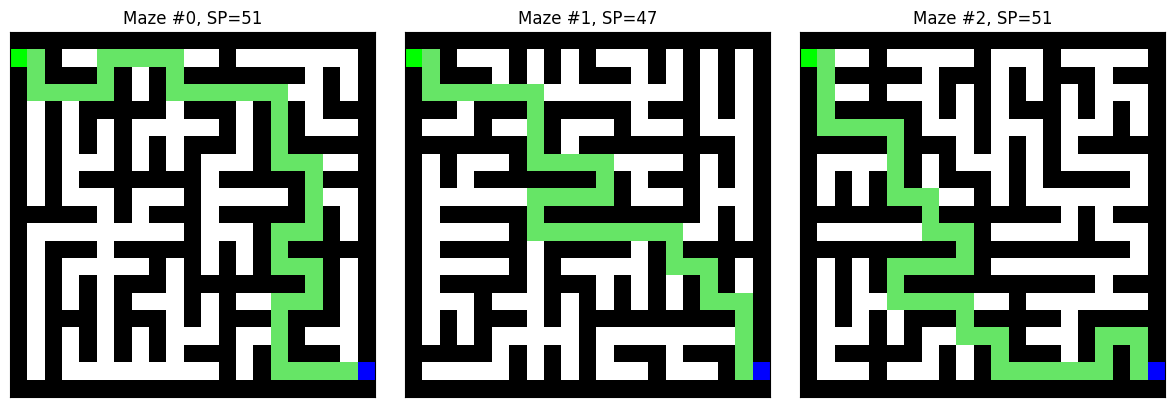

In [12]:
# Покажем три разных лабиринта с их кратчайшими путями
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, idx in zip(axes, [0, 1, 2]):
    img = np.stack([train_mazes[idx].astype(float)] * 3, axis=-1)
    # Раскрашиваем кратчайший путь зелёным
    sp = train_sp[idx]
    img[sp > 0.5] = [0.4, 0.9, 0.4]
    img[1, 0] = [0.0, 1.0, 0.0]      # вход
    img[19, 20] = [0.0, 0.0, 1.0]    # выход
    ax.imshow(img)
    ax.set_title(f"Maze #{idx}, SP={int(sp.sum())}")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()


## 7. Цикл обучения

Один и тот же `train_stage` используется для всех трёх этапов —
меняется только `stage` в среде и гиперпараметры из `STAGE_CONFIG`.

Параметры подобраны под **CPU**: `N_ENVS=16, N_STEPS=128`,
один rollout даёт 2048 переходов. На GPU имеет смысл ставить
`N_ENVS=64, N_STEPS=256` (16384 переходов) — будет быстрее
и стабильнее.

Кроме learning rate, коэффициента энтропии и числа итераций каждый этап
имеет свой `max_steps` — лимит шагов на эпизод. Логика проста:
средняя длина кратчайшего пути ≈ 50 клеток, и от этого пляшем:

* **Stage 1** (исследование) — `max_steps = 300`, ~6× от длины SP.
  Агенту нужен запас, чтобы случайным блужданием набрести на выход
  и получить позитивный сигнал награды.
* **Stage 2** (поиск выхода) — `max_steps = 200`, ~4× от длины SP.
  Модель уже умеет ходить, лимит можно ужать.
* **Stage 3** (кратчайший путь) — `max_steps = 120`, ~2.5× от длины SP.
  Тут уже почти нет права на ошибку; короткий лимит ускоряет обучение.

Логика early-stop: если в течение `patience` оценок подряд
success rate не растёт и средняя длина пути не уменьшается —
останавливаемся. Это экономит время на втором и третьем этапах,
когда модель уже почти оптимальна.

В логах виден ETA — примерное оставшееся время до конца стадии.


In [13]:
# --- Гиперпараметры цикла обучения ---
# Сколько лабиринтов агент проходит одновременно (параллельные среды).
# На GPU стоит ставить 64+, на CPU имеет смысл 16-32 (большие батчи мало
# что дают, а память на буфер растёт линейно).
N_ENVS = 16

# Сколько шагов в каждой среде между обновлениями сети.
# Один rollout даёт N_ENVS * N_STEPS = 2048 переходов, по которым
# крутится PPO update.
N_STEPS = 128

OBS_SHAPE = (5, 21, 21)

# Лимит шагов на эпизод. Используется как верхняя граница (для аллокаций
# и как дефолт в evaluate/run_episode). На каждом этапе обучения мы берём
# свой более тесный лимит из STAGE_CONFIG -- см. ниже.
# Откуда числа: средняя длина кратчайшего пути в 21x21 ~ 50 шагов.
#   - Stage 1 (исследование): запас x6 -> 300, чтобы агент успел набрести на выход
#   - Stage 2 (поиск выхода): запас x4 -> 200
#   - Stage 3 (кратчайший путь): запас x2.5 -> 120, ошибаться особо некуда
MAX_STEPS = 300


@torch.no_grad()
def evaluate(model, mazes, dists, sps, stage, max_steps=MAX_STEPS):
    """Прогон модели на eval-лабиринтах. Возвращает (success_rate, avg_steps)."""
    n = len(mazes)
    env = MazeEnv(mazes, n_envs=n, max_steps=max_steps, stage=stage,
                  dist_pool=dists, sp_pool=sps, seed=42)
    obs = env.observation()

    reached = np.zeros(n, dtype=bool)
    steps_taken = np.zeros(n, dtype=np.int32)
    finished = np.zeros(n, dtype=bool)

    for _ in range(max_steps):
        obs_t = torch.as_tensor(obs, device=device)
        action, _, _, _ = model.act(obs_t)
        a = action.cpu().numpy()
        obs, _, _, info = env.step(a)
        # Запоминаем результат первого завершения каждого эпизода
        new_done = (info["reached"] | info["timeout"]) & ~finished
        reached[new_done] = info["reached"][new_done]
        steps_taken[new_done] = info["steps"][new_done]
        finished |= new_done
        if finished.all():
            break

    success_rate = reached.mean()
    if reached.any():
        avg_steps = steps_taken[reached].mean()
    else:
        avg_steps = float(max_steps)
    return float(success_rate), float(avg_steps)


def plot_training_curves(history, title):
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

    keys = [("exit_rate", "Exit rate (train)"),
            ("avg_steps", "Avg steps"),
            ("policy_loss", "Policy loss"),
            ("entropy", "Entropy")]

    for ax, (key, label) in zip(axes, keys):
        data = history[key]
        ax.plot(data, alpha=0.3, color="tab:blue")
        # Сглаживание скользящим средним
        w = max(1, len(data) // 20)
        if len(data) > w:
            kernel = np.ones(w) / w
            smooth = np.convolve(data, kernel, mode="valid")
            ax.plot(range(w - 1, len(data)), smooth, color="tab:blue", lw=2)
        ax.set_title(label)
        ax.set_xlabel("iteration")
        ax.grid(alpha=0.3)

    if history["eval_sr"]:
        ax2 = axes[0].twinx()
        ax2.plot(history["eval_iter"], history["eval_sr"],
                 "r*-", ms=8, label="Eval SR")
        ax2.set_ylabel("Eval SR", color="r")
        ax2.legend(loc="lower right")

    fig.suptitle(title, fontsize=13)
    plt.tight_layout(); plt.show()


In [14]:
# CPU-friendly значения. На GPU имеет смысл увеличить iters в 2-3 раза.
STAGE_CONFIG = {
    1: dict(name="Исследование",   iters=600, lr=3e-4, ent_coef=0.02,
            target_kl=0.015, patience=15, max_steps=300),
    2: dict(name="Поиск выхода",   iters=400, lr=5e-5, ent_coef=0.015,
            target_kl=0.008, patience=10, max_steps=200),
    3: dict(name="Кратчайший путь", iters=400, lr=3e-5, ent_coef=0.01,
            target_kl=0.006, patience=10, max_steps=120),
}


def train_stage(stage, model):
    cfg = STAGE_CONFIG[stage]
    n_iter = cfg["iters"]
    patience = cfg["patience"]
    max_steps = cfg["max_steps"]

    print(f"\n{'=' * 60}")
    print(f"  STAGE {stage}: {cfg['name']}")
    print(f"  iters={n_iter}, lr={cfg['lr']}, ent={cfg['ent_coef']}, "
          f"max_steps={max_steps}, patience={patience}")
    print(f"{'=' * 60}")

    env = MazeEnv(train_mazes, n_envs=N_ENVS, max_steps=max_steps, stage=stage,
                  dist_pool=train_dist, sp_pool=train_sp, seed=stage)
    ppo = PPO(model, lr=cfg["lr"], clip=0.1, ent_coef=cfg["ent_coef"],
              val_coef=0.5, n_epochs=3, batch_size=256,
              target_kl=cfg["target_kl"], total_iters=n_iter)
    buffer = RolloutBuffer(N_STEPS, N_ENVS, OBS_SHAPE)
    obs = env.observation()

    history = {"exit_rate": [], "avg_steps": [], "policy_loss": [],
               "entropy": [], "eval_sr": [], "eval_iter": []}

    # На CPU итерации идут заметно: логируем каждую (или каждую 5-ю на больших iters).
    log_every = 1 if n_iter <= 200 else 5
    eval_every = max(10, n_iter // 20)

    best_sr = 0.0
    best_steps = float(max_steps)
    best_state = None
    no_improve = 0

    # Скользящие окна — сглаживают шум в early-stop и логах
    recent_exits = deque(maxlen=20)
    recent_steps_done = deque(maxlen=20)

    t0 = time.time()
    for it in range(1, n_iter + 1):
        it_start = time.time()
        obs, episodes = ppo.collect_rollout(env, buffer, obs)

        with torch.no_grad():
            last_v = model.act(torch.as_tensor(obs, device=device))[3].cpu().numpy()
        stats = ppo.update(buffer, last_v, env.done.astype(np.float32))

        # Метрики из эпизодов
        if episodes:
            exit_rate = sum(e["reached"] for e in episodes) / len(episodes)
            avg_steps = np.mean([e["steps"] for e in episodes])
            recent_exits.extend(e["reached"] for e in episodes)
            recent_steps_done.extend(e["steps"] for e in episodes if e["reached"])
        else:
            exit_rate = 0.0
            avg_steps = float(max_steps)

        history["exit_rate"].append(exit_rate)
        history["avg_steps"].append(avg_steps)
        history["policy_loss"].append(stats["policy_loss"])
        history["entropy"].append(stats["entropy"])

        if it % log_every == 0 or it == 1:
            elapsed = time.time() - t0
            it_time = time.time() - it_start
            eta_sec = it_time * (n_iter - it)
            eta_min = eta_sec / 60
            smoothed = np.mean(recent_exits) if recent_exits else 0.0
            print(f"  {it:4d}/{n_iter} | exit:{exit_rate:.0%} (avg20:{smoothed:.0%}) | "
                  f"steps:{avg_steps:.0f} | "
                  f"PL:{stats['policy_loss']:+.3f} | "
                  f"H:{stats['entropy']:.3f} | KL:{stats['kl']:.3f} | "
                  f"{it_time:.1f}s/it | ETA:{eta_min:.0f}min", flush=True)

        if it % eval_every == 0:
            sr, avs = evaluate(model, eval_mazes, eval_dist, eval_sp, stage,
                               max_steps=max_steps)
            history["eval_sr"].append(sr)
            history["eval_iter"].append(it)

            improved = (sr > best_sr + 0.01) or \
                       (sr >= best_sr - 0.01 and avs < best_steps - 2)
            if improved:
                best_sr = max(sr, best_sr)
                best_steps = min(avs, best_steps)
                best_state = copy.deepcopy(model.state_dict())
                no_improve = 0
                print(f"        eval: success={sr:.1%}, avg_steps={avs:.1f}  *** BEST", flush=True)
            else:
                no_improve += 1
                print(f"        eval: success={sr:.1%}, avg_steps={avs:.1f}  "
                      f"(no improve {no_improve}/{patience})", flush=True)

            if no_improve >= patience:
                print(f"  early stop на итерации {it}", flush=True)
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"  Загружен лучший чекпоинт: SR={best_sr:.1%}, steps={best_steps:.1f}")

    final_sr, final_steps = evaluate(model, eval_mazes, eval_dist, eval_sp, stage,
                                     max_steps=max_steps)
    total_min = (time.time() - t0) / 60
    print(f"  Финальный результат: SR={final_sr:.1%}, steps={final_steps:.1f}  "
          f"(всего {total_min:.1f} мин)")
    plot_training_curves(history, f"Stage {stage}: {cfg['name']}")
    return model


### Stage 1 — Исследование

Цель — научить агента вообще ходить по лабиринту и посещать
новые клетки. Награда: `+0.05` за каждую новую клетку, `+1.0`
за достижение выхода.


Параметров: 7,525,253

  STAGE 1: Исследование
  iters=600, lr=0.0003, ent=0.02, max_steps=300, patience=15
     1/600 | exit:0% (avg20:0%) | steps:300 | PL:+0.034 | H:1.366 | KL:0.023 | 8.4s/it | ETA:83min
     5/600 | exit:0% (avg20:0%) | steps:300 | PL:-0.001 | H:1.373 | KL:0.001 | 19.7s/it | ETA:196min
    10/600 | exit:0% (avg20:0%) | steps:300 | PL:-0.002 | H:1.313 | KL:0.002 | 19.6s/it | ETA:193min
    15/600 | exit:0% (avg20:5%) | steps:300 | PL:-0.001 | H:1.294 | KL:0.002 | 18.9s/it | ETA:184min
    20/600 | exit:0% (avg20:5%) | steps:300 | PL:-0.003 | H:1.306 | KL:0.003 | 20.1s/it | ETA:194min
    25/600 | exit:0% (avg20:0%) | steps:300 | PL:-0.003 | H:1.268 | KL:0.002 | 19.7s/it | ETA:189min
    30/600 | exit:0% (avg20:0%) | steps:300 | PL:-0.003 | H:1.284 | KL:0.002 | 19.7s/it | ETA:187min
        eval: success=1.5%, avg_steps=249.7  *** BEST
    35/600 | exit:0% (avg20:0%) | steps:300 | PL:-0.002 | H:1.318 | KL:0.002 | 19.7s/it | ETA:186min
    40/600 | exit:0% (avg20:0%) 

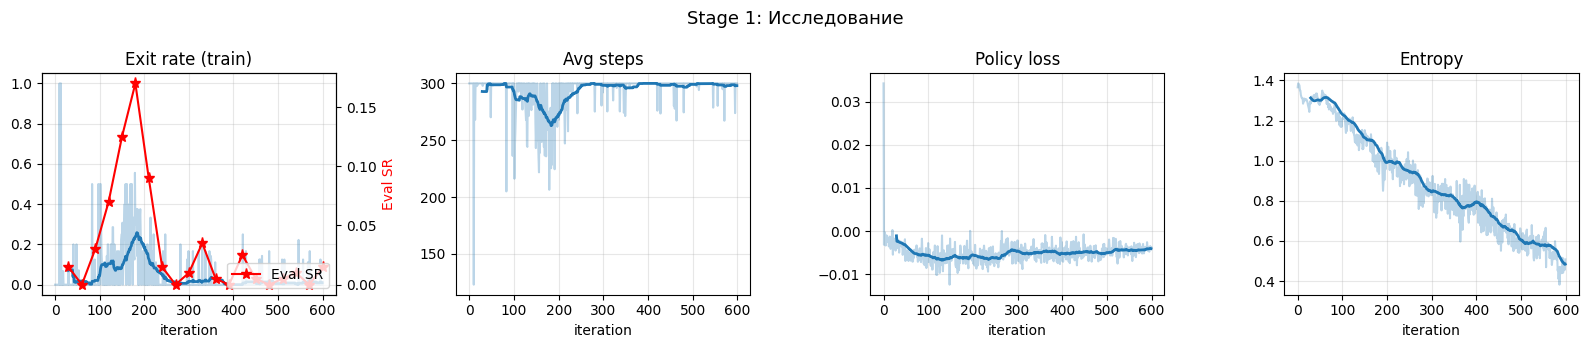

In [15]:
model = MazeNet().to(device)
print(f"Параметров: {sum(p.numel() for p in model.parameters()):,}")
model = train_stage(1, model)
torch.save(model.state_dict(), "maze_stage1.pt")


### Stage 2 — Поиск выхода

Теперь агент уже умеет ходить — научим его доходить до выхода
быстрее. Каждый шаг штрафуется на `0.01`, выход — `+1.0`.



  STAGE 2: Поиск выхода
  iters=400, lr=5e-05, ent=0.015, max_steps=200, patience=10
     1/400 | exit:0% (avg20:0%) | steps:200 | PL:-0.003 | H:0.998 | KL:0.005 | 13.6s/it | ETA:90min
     5/400 | exit:0% (avg20:10%) | steps:200 | PL:-0.006 | H:1.053 | KL:0.001 | 19.3s/it | ETA:127min
    10/400 | exit:7% (avg20:10%) | steps:194 | PL:-0.005 | H:1.068 | KL:0.001 | 19.3s/it | ETA:125min
    15/400 | exit:8% (avg20:10%) | steps:191 | PL:-0.004 | H:1.017 | KL:0.002 | 19.3s/it | ETA:124min
    20/400 | exit:11% (avg20:10%) | steps:186 | PL:-0.005 | H:0.992 | KL:0.001 | 19.3s/it | ETA:122min
        eval: success=14.0%, avg_steps=139.1  *** BEST
    25/400 | exit:12% (avg20:10%) | steps:192 | PL:-0.005 | H:1.014 | KL:0.001 | 19.2s/it | ETA:120min
    30/400 | exit:45% (avg20:30%) | steps:173 | PL:-0.004 | H:0.896 | KL:0.001 | 19.2s/it | ETA:119min
    35/400 | exit:22% (avg20:15%) | steps:179 | PL:-0.005 | H:0.994 | KL:0.001 | 19.3s/it | ETA:118min
    40/400 | exit:25% (avg20:15%) | steps

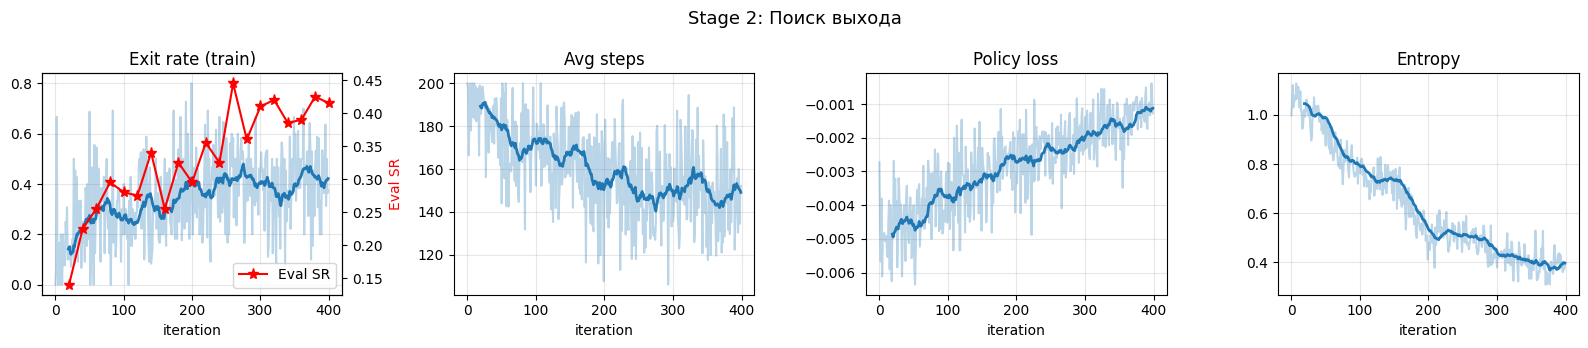

In [16]:
model = train_stage(2, model)
torch.save(model.state_dict(), "maze_stage2.pt")


### Stage 3 — Кратчайший путь

Финальная фаза: агент знает где находится кратчайший путь
(награда передаёт ему эту информацию). За шаг по SP — бонус,
за шаг вне SP — штраф.



  STAGE 3: Кратчайший путь
  iters=400, lr=3e-05, ent=0.01, max_steps=120, patience=10
     1/400 | exit:29% (avg20:29%) | steps:102 | PL:-0.004 | H:0.457 | KL:0.001 | 19.5s/it | ETA:129min
     5/400 | exit:44% (avg20:45%) | steps:92 | PL:-0.004 | H:0.404 | KL:0.001 | 19.3s/it | ETA:127min
    10/400 | exit:37% (avg20:35%) | steps:96 | PL:-0.003 | H:0.419 | KL:0.001 | 19.3s/it | ETA:125min
    15/400 | exit:48% (avg20:45%) | steps:96 | PL:-0.003 | H:0.418 | KL:0.001 | 19.2s/it | ETA:123min
    20/400 | exit:11% (avg20:10%) | steps:115 | PL:-0.004 | H:0.473 | KL:0.001 | 19.3s/it | ETA:122min
        eval: success=29.0%, avg_steps=66.7  *** BEST
    25/400 | exit:17% (avg20:20%) | steps:111 | PL:-0.002 | H:0.396 | KL:0.001 | 19.3s/it | ETA:121min
    30/400 | exit:32% (avg20:35%) | steps:108 | PL:-0.003 | H:0.440 | KL:0.001 | 19.3s/it | ETA:119min
    35/400 | exit:28% (avg20:25%) | steps:109 | PL:-0.003 | H:0.399 | KL:0.001 | 19.3s/it | ETA:117min
    40/400 | exit:38% (avg20:40%) | s

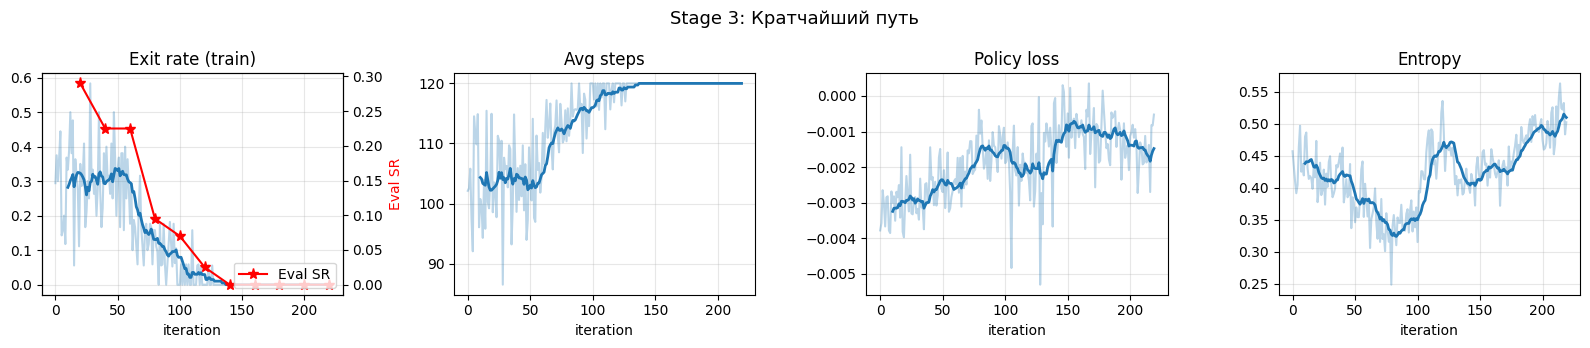

In [17]:
model = train_stage(3, model)
torch.save(model.state_dict(), "maze_stage3.pt")


## 8. Итоговая оценка

Прогоняем все три стадии награды на eval-лабиринтах и
смотрим, как обученная модель ведёт себя по каждой метрике.


In [18]:
print("=" * 60)
print(" ИТОГОВЫЕ МЕТРИКИ НА EVAL-НАБОРЕ")
print("=" * 60)
sp_avg = eval_sp.sum(axis=(1, 2)).mean()
print(f" Средний кратчайший путь: {sp_avg:.1f}\n")
for stage in [1, 2, 3]:
    ms = STAGE_CONFIG[stage]["max_steps"]
    sr, avs = evaluate(model, eval_mazes, eval_dist, eval_sp, stage, max_steps=ms)
    print(f"  Stage {stage} ({STAGE_CONFIG[stage]['name']:>17}, max={ms}): "
          f"success {sr:.1%},  avg steps {avs:.1f}")


 ИТОГОВЫЕ МЕТРИКИ НА EVAL-НАБОРЕ
 Средний кратчайший путь: 50.0

  Stage 1 (     Исследование, max=300): success 37.0%,  avg steps 86.6
  Stage 2 (     Поиск выхода, max=200): success 33.0%,  avg steps 83.4
  Stage 3 (  Кратчайший путь, max=120): success 28.0%,  avg steps 67.4


## 9. Визуализация решений

Для нескольких случайных лабиринтов из eval-набора рисуем:

* путь, который выбрала модель (красный);
* кратчайший путь (зелёный);
* пересечение — где модель шла по оптимальному маршруту (синий).


In [19]:
@torch.no_grad()
def run_episode(model, maze, sp_mask, max_steps=400, capture_features=False):
    """Прогоняет один эпизод. Опционально сохраняет промежуточные активации сети."""
    env = MazeEnv(maze[None], n_envs=1, max_steps=max_steps, stage=1,
                  sp_pool=sp_mask[None] if sp_mask is not None else None,
                  seed=0)
    obs = env.observation()

    path = [(env.cur_r[0], env.cur_c[0])]
    feature_maps = []           # активации после ResBlock'ов
    policy_logits_list = []

    for _ in range(max_steps):
        obs_t = torch.as_tensor(obs, device=device)
        if capture_features:
            features = model.features(obs_t)            # (1, C, 21, 21)
            feature_maps.append(features[0].cpu().numpy())
        logits, _ = model.forward(obs_t)
        policy_logits_list.append(logits[0].cpu().numpy())

        action = logits.argmax(dim=-1)                  # детерминированно
        a = action.cpu().numpy()
        obs, _, done, info = env.step(a)
        path.append((env.cur_r[0], env.cur_c[0]))
        if done[0]:
            break

    reached = bool(info["reached"][0])
    return {
        "path": path,
        "reached": reached,
        "steps": int(info["steps"][0]),
        "feature_maps": feature_maps,
        "logits": policy_logits_list,
    }


def plot_solution(maze, sp_mask, episode):
    path = episode["path"]
    on_sp = sum(1 for r, c in set(path) if sp_mask[r, c] > 0.5)
    sp_len = int(sp_mask.sum())

    fig, axes = plt.subplots(1, 2, figsize=(11, 5))

    # Слева: маршрут агента
    img = np.stack([maze.astype(float)] * 3, axis=-1)
    for r, c in path:
        img[r, c] = [1.0, 0.4, 0.4]
    img[1, 0] = [0.0, 1.0, 0.0]
    img[19, 20] = [0.0, 0.4, 1.0]
    axes[0].imshow(img)
    status = "OK" if episode["reached"] else "FAIL"
    axes[0].set_title(f"Путь агента ({len(path)} шагов, {status})")

    # Справа: маршрут поверх кратчайшего
    img2 = np.stack([maze.astype(float)] * 3, axis=-1)
    img2[sp_mask > 0.5] = [0.4, 0.9, 0.4]               # SP — зелёный
    for r, c in path:
        if sp_mask[r, c] > 0.5:
            img2[r, c] = [0.2, 0.4, 1.0]                # на SP — синий
        else:
            img2[r, c] = [1.0, 0.4, 0.4]                # вне SP — красный
    img2[1, 0] = [0.0, 1.0, 0.0]
    img2[19, 20] = [0.0, 0.4, 1.0]
    axes[1].imshow(img2)
    axes[1].set_title(f"Сравнение с SP ({on_sp}/{sp_len} клеток на пути)")
    axes[1].legend(handles=[
        mpatches.Patch(color=(0.4, 0.9, 0.4), label="Кратчайший путь"),
        mpatches.Patch(color=(0.2, 0.4, 1.0), label="Агент на SP"),
        mpatches.Patch(color=(1.0, 0.4, 0.4), label="Агент вне SP"),
    ], loc="lower right", fontsize=8)

    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout(); plt.show()


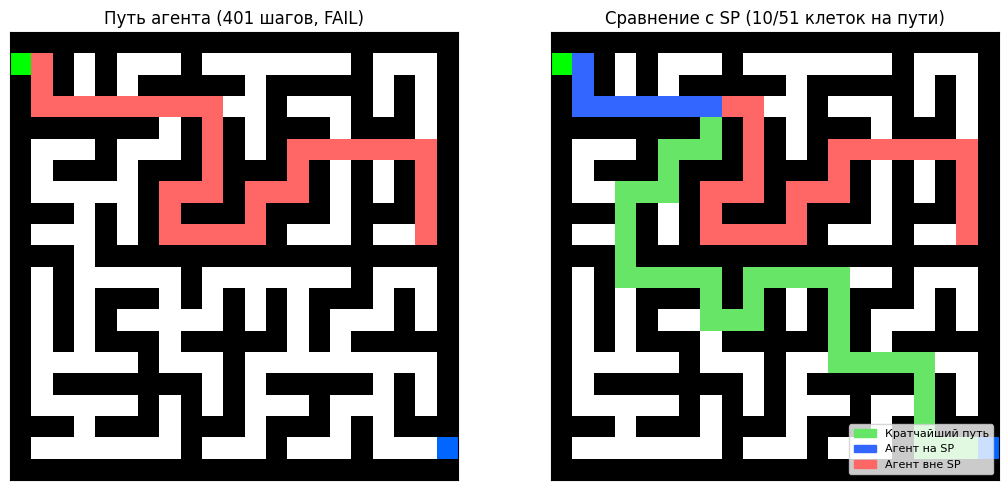

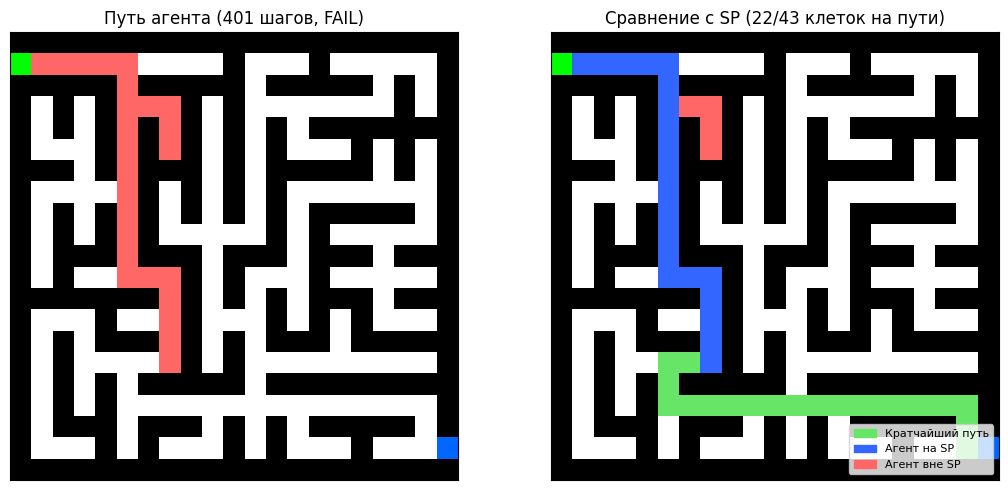

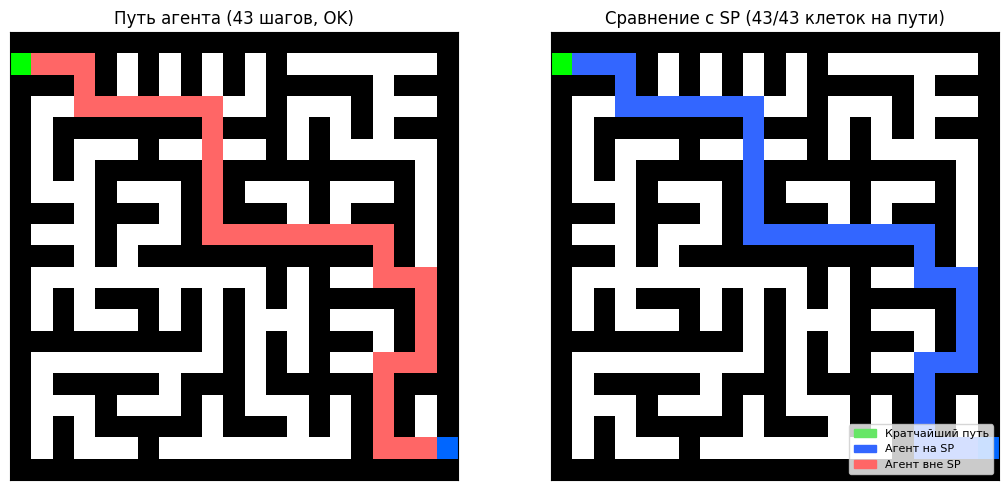

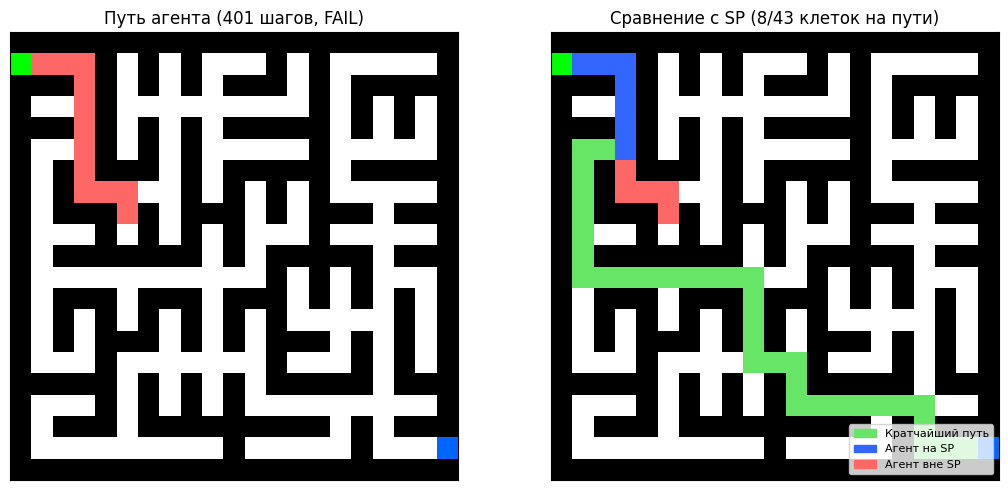

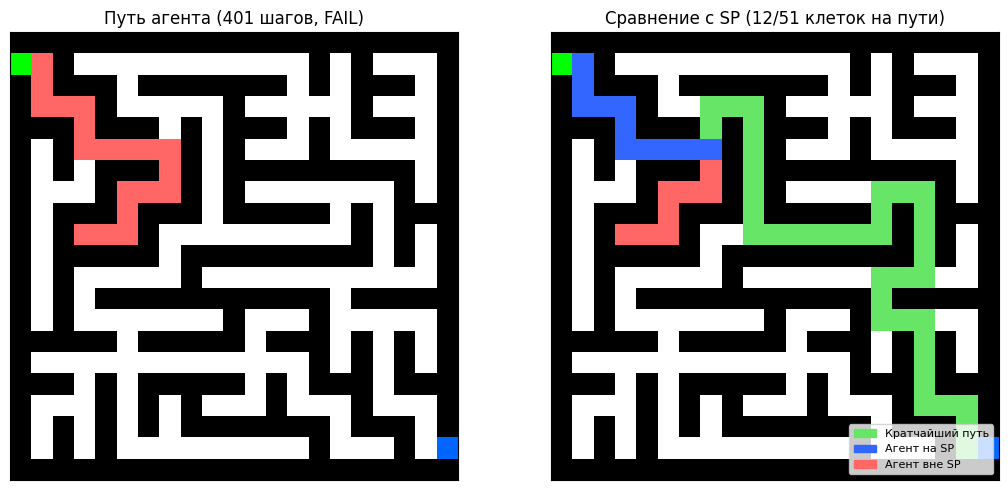

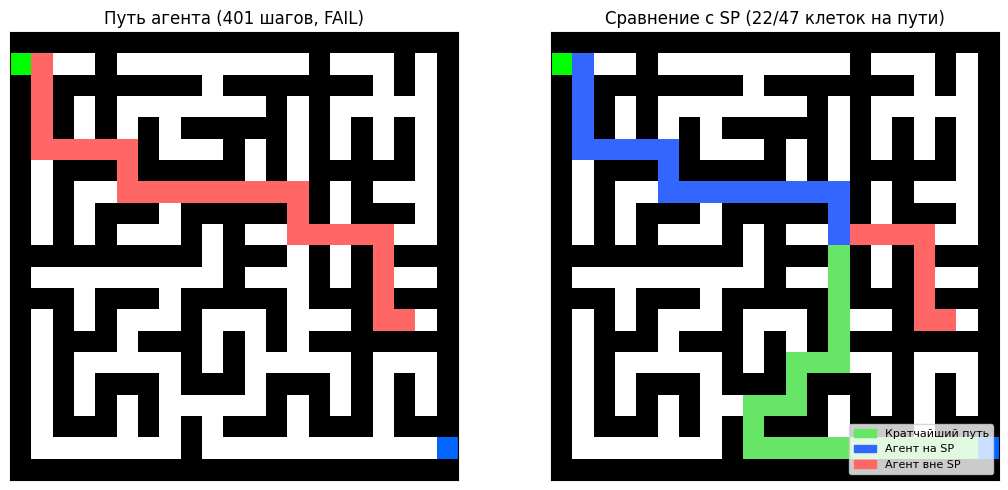

In [24]:
# Покажем 6 случайных лабиринтов с обученной моделью
np.random.seed(77)
indices = np.random.choice(len(eval_mazes), size=6, replace=False)
for idx in indices:
    ep = run_episode(model, eval_mazes[idx], eval_sp[idx])
    plot_solution(eval_mazes[idx], eval_sp[idx], ep)


## 10. Визуализация активаций сети

Покажем, во что "смотрит" свёрточная сеть. Усредним активации
после последнего ResBlock'a по каналам — получим тепловую карту,
показывающую где у сети наибольшая активность.


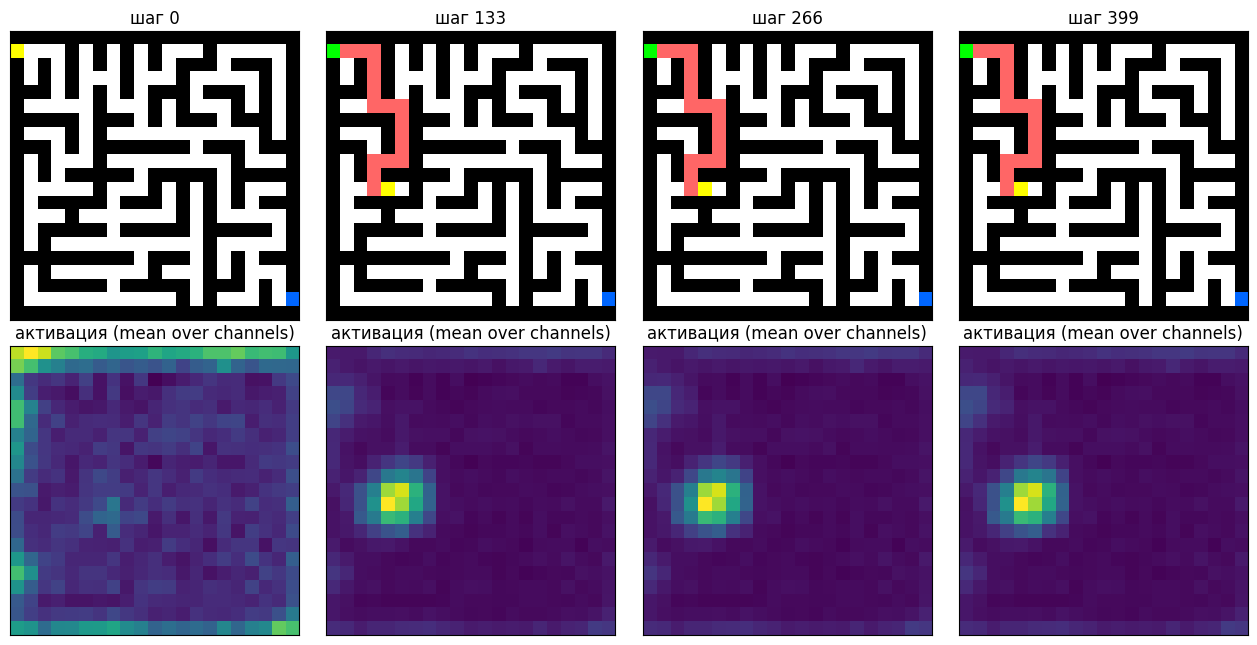

In [25]:
def plot_activations(model, maze, sp_mask, n_steps=4):
    """Берём несколько шагов эпизода и рисуем активации сети для каждого."""
    ep = run_episode(model, maze, sp_mask, capture_features=True)
    feats = ep["feature_maps"]

    if len(feats) == 0:
        print("эпизод пустой?")
        return

    # Берём равномерно n_steps кадров эпизода
    if len(feats) <= n_steps:
        chosen = list(range(len(feats)))
    else:
        chosen = np.linspace(0, len(feats) - 1, n_steps, dtype=int).tolist()

    fig, axes = plt.subplots(2, len(chosen), figsize=(3.2 * len(chosen), 6.5))
    if len(chosen) == 1:
        axes = axes.reshape(2, 1)

    for col, t in enumerate(chosen):
        # Верхний ряд: лабиринт с траекторией агента до момента t
        img = np.stack([maze.astype(float)] * 3, axis=-1)
        for r, c in ep["path"][:t + 1]:
            img[r, c] = [1.0, 0.4, 0.4]
        img[1, 0] = [0.0, 1.0, 0.0]
        img[19, 20] = [0.0, 0.4, 1.0]
        cur_r, cur_c = ep["path"][t]
        img[cur_r, cur_c] = [1.0, 1.0, 0.0]              # текущая клетка
        axes[0, col].imshow(img)
        axes[0, col].set_title(f"шаг {t}")
        axes[0, col].set_xticks([]); axes[0, col].set_yticks([])

        # Нижний ряд: усреднённая по каналам карта активаций
        heat = feats[t].mean(axis=0)
        axes[1, col].imshow(heat, cmap="viridis")
        axes[1, col].set_title("активация (mean over channels)")
        axes[1, col].set_xticks([]); axes[1, col].set_yticks([])

    plt.tight_layout(); plt.show()


# Покажем активации для одного eval-лабиринта
np.random.seed(42)
idx = np.random.randint(len(eval_mazes))
plot_activations(model, eval_mazes[idx], eval_sp[idx], n_steps=4)


## 11. Странные лабиринты

Среда не делает никаких предположений о структуре лабиринта —
она просто принимает любой массив `21×21` со значениями 0/1.
Поэтому обученную модель можно запустить на нестандартных
лабиринтах: с лишними проходами, с проходами по диагонали
(в смысле "много развилок"), с разреженными стенами и т.д.

Посмотрим, как наша модель справляется на нескольких сгенерированных
вручную "странных" примерах.


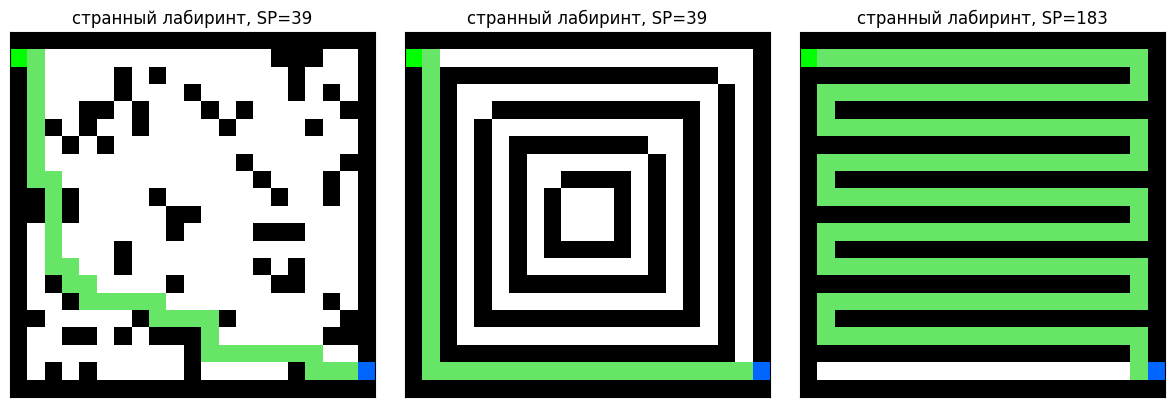

In [22]:
def make_open_room(noise=0.1):
    """Почти пустая комната с редкими стенками."""
    maze = np.ones((21, 21), dtype=np.int32)
    # Внешние стены
    maze[0, :] = 0; maze[-1, :] = 0
    maze[:, 0] = 0; maze[:, -1] = 0
    # Случайные внутренние стены
    inner = np.random.random((19, 19)) < noise
    maze[1:-1, 1:-1] = (~inner).astype(np.int32)
    # Открываем вход и выход
    maze[1, 0] = 1
    maze[19, 20] = 1
    # Гарантируем достижимость целевой клетки от входа
    if bfs_distances(maze)[1, 0] >= 9999:
        return make_open_room(noise * 0.5)
    return maze


def make_spiral():
    """Лабиринт-спираль."""
    maze = np.ones((21, 21), dtype=np.int32)
    maze[0, :] = 0; maze[-1, :] = 0
    maze[:, 0] = 0; maze[:, -1] = 0
    # Концентрические "полки"
    for k in range(2, 9, 2):
        maze[k, k:21 - k] = 0
        maze[20 - k, k:21 - k] = 0
        maze[k:21 - k, k] = 0
        maze[k:21 - k, 20 - k] = 0
        # Прорезаем проходы (разрываем кольцо)
        if k % 4 == 2:
            maze[k, 21 - k - 1] = 1
        else:
            maze[k, k] = 1
    maze[1, 0] = 1
    maze[19, 20] = 1
    return maze


def make_long_corridors():
    """Параллельные коридоры с переходами на концах."""
    maze = np.zeros((21, 21), dtype=np.int32)
    # Горизонтальные коридоры на нечётных строках
    for r in range(1, 21, 2):
        maze[r, 1:20] = 1
    # Соединения на левом и правом краях, чередуя
    for r in range(1, 19, 4):
        maze[r:r + 3, 19] = 1
    for r in range(3, 19, 4):
        maze[r:r + 3, 1] = 1
    maze[1, 0] = 1
    maze[19, 20] = 1
    return maze


# Сгенерируем три странных примера
np.random.seed(0)
weird_mazes = np.stack([
    make_open_room(noise=0.18),
    make_spiral(),
    make_long_corridors(),
])
weird_sp = np.stack([shortest_path_mask(m) for m in weird_mazes])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, m, sp in zip(axes, weird_mazes, weird_sp):
    img = np.stack([m.astype(float)] * 3, axis=-1)
    img[sp > 0.5] = [0.4, 0.9, 0.4]
    img[1, 0] = [0.0, 1.0, 0.0]
    img[19, 20] = [0.0, 0.4, 1.0]
    ax.imshow(img)
    ax.set_title(f"странный лабиринт, SP={int(sp.sum())}")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()


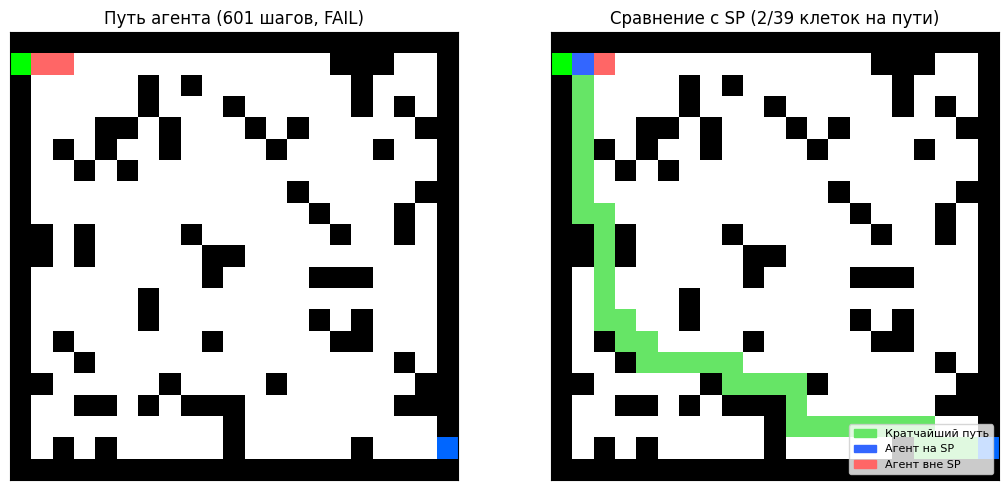

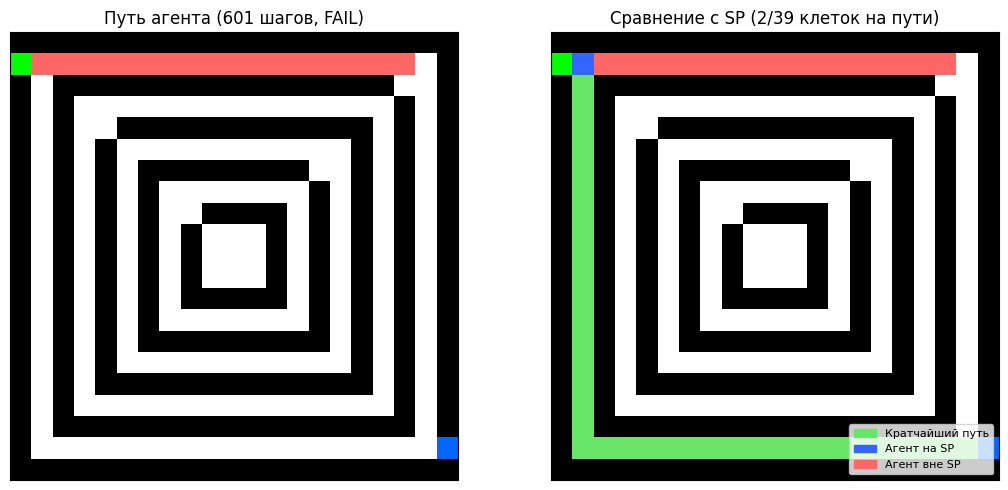

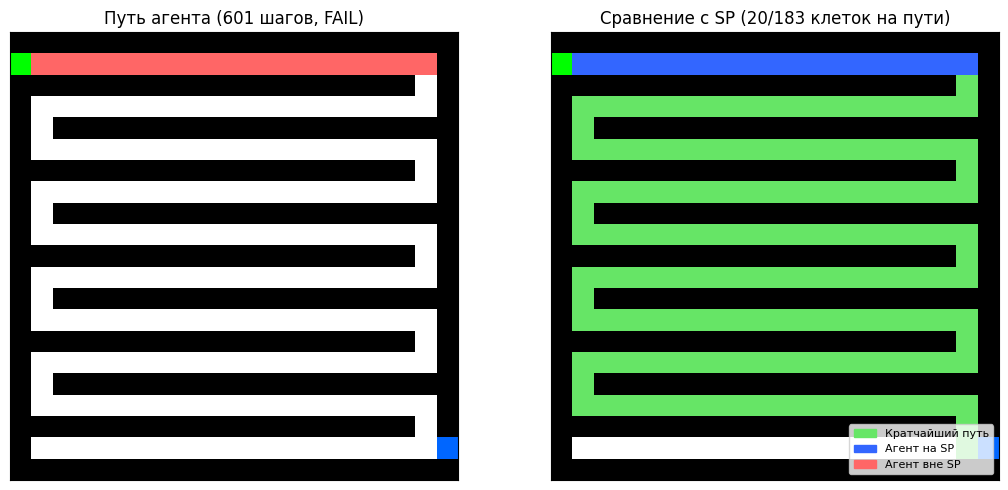

In [23]:
# Прогоняем нашу модель на странных лабиринтах
for i in range(len(weird_mazes)):
    ep = run_episode(model, weird_mazes[i], weird_sp[i], max_steps=600)
    plot_solution(weird_mazes[i], weird_sp[i], ep)


---

### Что получилось

* Среда — `MazeEnv`, чистый numpy, поддерживает множество игр одновременно
  с авто-рестартом. Наблюдение — one-hot значений 0..4 (стена, коридор,
  посещено, последняя, текущая).
* Модель — Actor-Critic с residual-блоками без даунсэмплинга;
  пространственное разрешение `21×21` сохраняется до самой "шеи".
* Алгоритм — PPO с GAE, KL early stop, линейным спадом LR,
  энтропийным бонусом и нормализацией advantage.
* Обучение — три независимых этапа с разными функциями награды;
  каждый этап стартует с весов предыдущего и тонко их подстраивает.

### Идеи для улучшения

* **Случайный старт.** Сейчас вход всегда `(1, 0)`. Если случайно
  начинать в любой клетке коридора, модель будет лучше обобщать.
* **LSTM / трансформер.** История посещений сейчас закодирована
  в one-hot канале. Рекуррентная политика могла бы запоминать
  контекст лучше.
* **Curriculum по сложности лабиринта.** Сначала маленькие,
  потом 21×21 — обучение шло бы быстрее.
